In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dataset=pd.read_csv("50_Startups.csv")

In [4]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [5]:
dataset=pd.get_dummies(dataset, drop_first=True)

In [6]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [7]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [8]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [9]:
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [10]:
dependent=dataset['Profit']

In [11]:
dependent

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [12]:
regressor=RandomForestRegressor()
#-----------K-Fold--------------#
kfold = KFold(n_splits=5, shuffle=True, random_state=None)

scores = cross_val_score(estimator=regressor, X=independent, y=dependent, cv=kfold)
#-----------K-Fold--------------#
print("="*60)
print("R2 Score for each fold:", scores)
print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())
print("="*60)

R2 Score for each fold: [0.84472816 0.89043983 0.92894234 0.9362041  0.95811779]
Mean R2: 0.9116864429773976
Standard Deviation: 0.03997394490857054


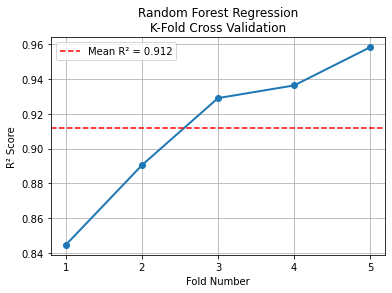

In [15]:
# K-Fold R² Score Plot-shows the model's performance on each fold.
folds = np.arange(1, len(scores)+1)

plt.figure(figsize=(6,4))

plt.plot(folds, scores, marker='o', linewidth=2)

plt.axhline(
    y=scores.mean(),
    color='red',
    linestyle='--',
    label=f"Mean R² = {scores.mean():.3f}"
)

plt.title("Random Forest Regression\nK-Fold Cross Validation")
plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.xticks(folds)
plt.legend()
plt.grid(True)

plt.show()

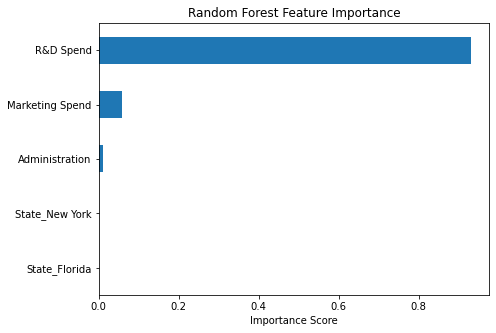

In [14]:
# Feature Importance-One of the biggest strengths of Random Forest is identifying which features matter most
regressor.fit(independent, dependent)

importance = pd.Series(
    regressor.feature_importances_,
    index=independent.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(7,5)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

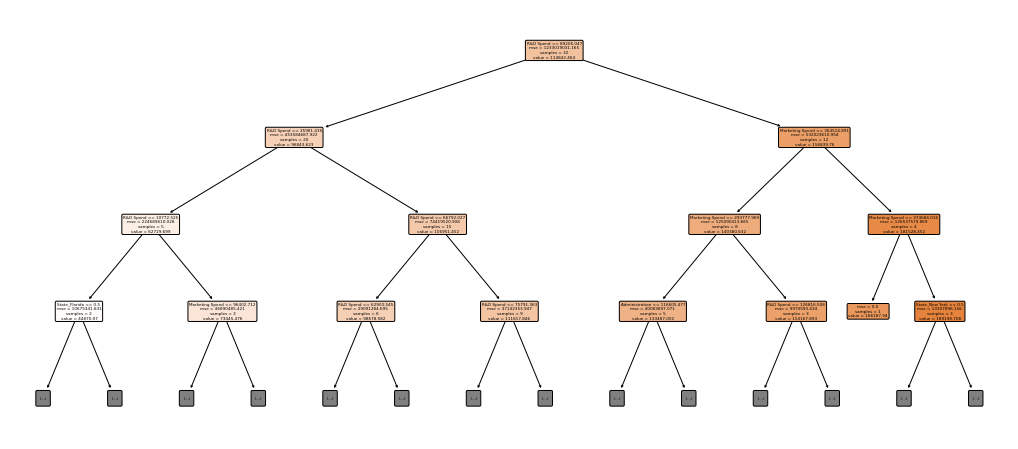

In [16]:
# Visualize One Tree-Random Forest consists of many decision trees.
from sklearn import tree

single_tree = regressor.estimators_[0]

plt.figure(figsize=(18,8))

tree.plot_tree(
    single_tree,
    feature_names=independent.columns,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()

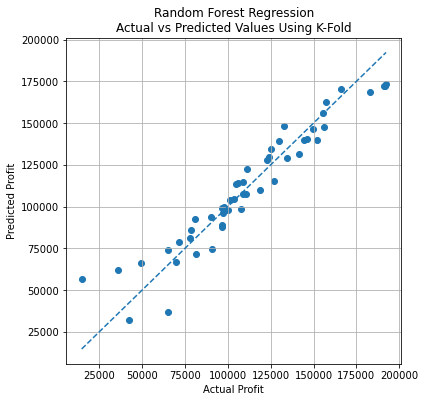

In [20]:
# Generate one out-of-fold prediction for every row
predictions = cross_val_predict( # Not this is not cross_val_score
    estimator=regressor,
    X=independent,
    y=dependent,
    cv=kfold
)

plt.figure(figsize=(6, 6))

plt.scatter(dependent, predictions)

# Perfect-prediction reference line
minimum = min(dependent.min(), predictions.min())
maximum = max(dependent.max(), predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Random Forest Regression\nActual vs Predicted Values Using K-Fold")

plt.grid(True)
plt.show()